In [153]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [154]:
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

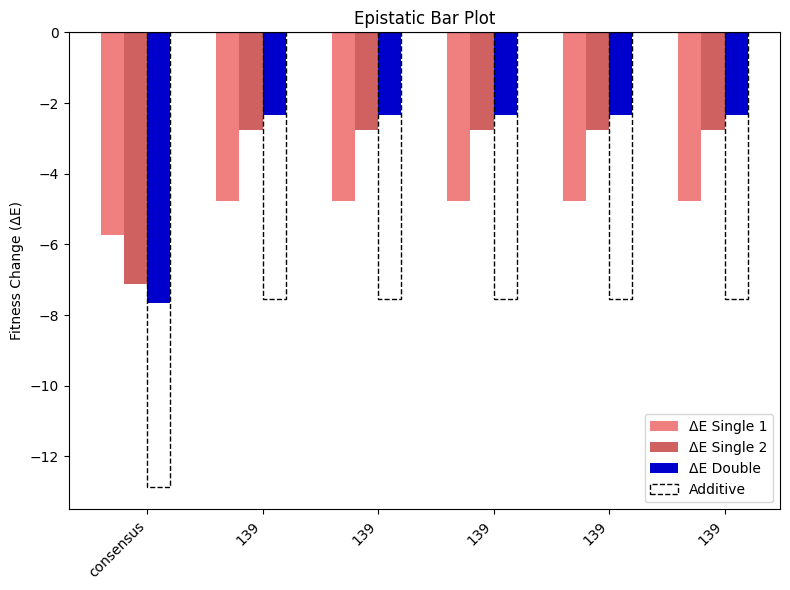

In [155]:
# IN_pair = 'G140S-Q148H'
# IN_pair = 'Y143C-S230R'
# IN_pair = 'G140A-Q148K'
# IN_pair = 'G140S-Q148R'
IN_pair = 'G140S-Q148K'
pair1, pair2 = functions.split_pairs(IN_pair)
p1_reduced = functions.unreduced_to_reduced(IN_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(IN_redux, pair2)

IN_bars = []
consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, IN_consensus_seq, IN_J, 1, 263)

for IN_seq in IN_all_seq:
    # Debugging: Print inputs to the function

    result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, IN_seq, IN_J, 1, 263)
    
    # Check if the result is None
    if result is None:
        # print(f"Warning: result is None for sequence {IN_all_seq.index(IN_seq)}")
        continue  # Skip this sequence
    
    pair1_de, pair2_de, pair12_de, pair12_dde = result
    # print((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_dde))
    IN_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))

IN_bars.sort(key=lambda x: x[3], reverse=True)
IN_bars.insert(0, ('consensus', consensus_result[0], consensus_result[1], consensus_result[2]))
# print("IN_bars:", IN_bars)
plot.plot_epistatic_bar(IN_bars[:6])

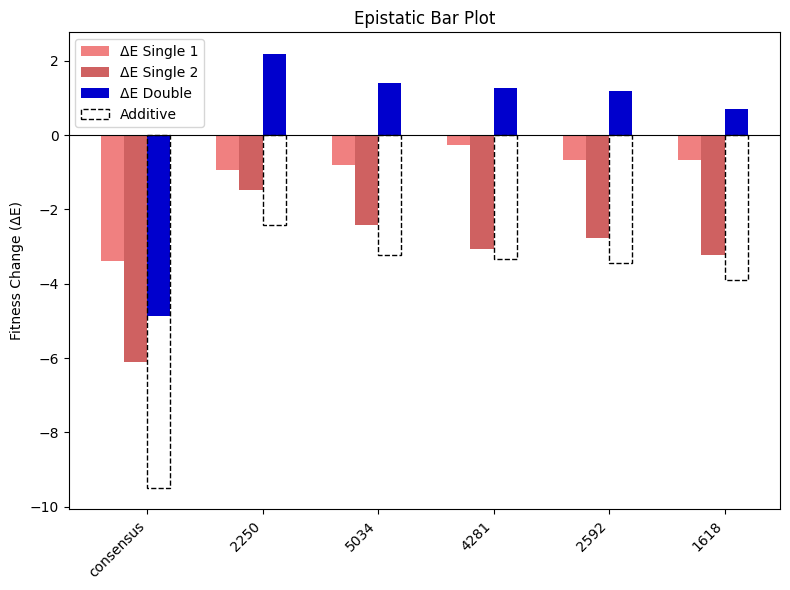

In [156]:
PR_pair = 'D30N-N88D'
# PR_pair = 'V32I-I47V'
# PR_pair = 'G48V-I54A'
# PR_pair = 'D30N-K45Q'
# PR_pair = 'I54A-V82A'

pair1, pair2 = functions.split_pairs(PR_pair)
p1_reduced = functions.unreduced_to_reduced(PR_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(PR_redux, pair2)

PR_bars = []
consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, PR_consensus_seq, PR_J, 1, 99)

for PR_seq in PR_all_seq:
    # Debugging: Print inputs to the function

    result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, PR_seq, PR_J, 1, 99)
    
    # Check if the result is None
    if result is None:
        # print(f"Warning: result is None for sequence {IN_all_seq.index(IN_seq)}")
        continue  # Skip this sequence
    
    pair1_de, pair2_de, pair12_de, pair12_dde = result
    # print((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_dde))
    PR_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))

PR_bars.sort(key=lambda x: x[3], reverse=True)
PR_bars.insert(0, ('consensus', consensus_result[0], consensus_result[1], consensus_result[2]))
# print("IN_bars:", IN_bars)
plot.plot_epistatic_bar(PR_bars[:6])

In [157]:
print(functions.get_mutations_from_sequence(IN_consensus_seq,IN_all_seq[571]))
print(functions.get_mutations_from_sequence(IN_consensus_seq,IN_all_seq[719]))
print(functions.get_mutations_from_sequence(IN_consensus_seq,IN_all_seq[360]))
print(functions.get_mutations_from_sequence(IN_consensus_seq,IN_all_seq[356]))
print(functions.get_mutations_from_sequence(IN_consensus_seq,IN_all_seq[407]))

['C31A', 'B45D', 'A56B', 'A72D', 'D125B', 'D138A', 'A167B', 'A188B']
['A14B', 'C31A', 'C113D', 'C124A', 'D125A', 'A193C', 'B201A', 'B205A', 'B206A', 'D218C', 'B231A', 'B254D']
['B6D', 'C7A', 'C10B', 'B20A', 'A72D', 'D119C', 'C122D', 'D125A', 'A203B', 'B206A']
['C10B', 'A41C', 'A101B', 'C122B', 'C124A', 'D125A', 'B201A', 'C208A']
['A11B', 'A28B', 'A37B', 'D39A', 'C50A', 'A72D', 'D112A', 'C124A', 'D125A', 'A167B', 'B201A', 'D253A']


In [158]:
test_mutations = ['C31A', 'B45D', 'A56B', 'A72D', 'D125B', 'D138A', 'A167B', 'A188B']
test_mutations = ['C31A', 'B45D', 'A56B', 'A72D', 'D125B', 'D138A', 'A167B', 'A188B']
test_mutations = ['A1C']
test_seq = functions.generate_sequence_from_mutations(IN_consensus_seq,test_mutations)
test_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, test_seq, IN_J, 1, 263)
print(test_result)

None


In [159]:
all_muations = set()
for seq in IN_all_seq:
    muts = functions.get_mutations_from_sequence(IN_consensus_seq,seq)
    for m in muts:
        all_muations.add(m)
print(sorted(all_muations))

['A100B', 'A100C', 'A101B', 'A101C', 'A103B', 'A110B', 'A117B', 'A11B', 'A127B', 'A128B', 'A128C', 'A134B', 'A134C', 'A139B', 'A13B', 'A142B', 'A142C', 'A144B', 'A14B', 'A151B', 'A153B', 'A154B', 'A154C', 'A155B', 'A155C', 'A161B', 'A161C', 'A161D', 'A162B', 'A163B', 'A163C', 'A163D', 'A167B', 'A168B', 'A170B', 'A170C', 'A171B', 'A171C', 'A171D', 'A176B', 'A179B', 'A179C', 'A181B', 'A188B', 'A193B', 'A193C', 'A193D', 'A196B', 'A196C', 'A198B', 'A203B', 'A214B', 'A222B', 'A222C', 'A222D', 'A224B', 'A225B', 'A242B', 'A248B', 'A263B', 'A28B', 'A28C', 'A30B', 'A30C', 'A30D', 'A32B', 'A35B', 'A36B', 'A37B', 'A3B', 'A3C', 'A3D', 'A41B', 'A41C', 'A54B', 'A55B', 'A55C', 'A56B', 'A71B', 'A71C', 'A72B', 'A72C', 'A72D', 'A73B', 'A74B', 'A74C', 'A74D', 'A87B', 'A89B', 'A89C', 'A92B', 'A92C', 'A92D', 'A93B', 'A93C', 'A96B', 'A96C', 'A97B', 'A97C', 'A9B', 'B104A', 'B104C', 'B106A', 'B111A', 'B111C', 'B111D', 'B114A', 'B121A', 'B12A', 'B135A', 'B135C', 'B137A', 'B141A', 'B147A', 'B150A', 'B157A', 'B1

In [160]:
mutations = []
for i in range(1,264):
    if i == functions.get_pos(p1_reduced) or i == functions.get_pos(p2_reduced):
        continue
    current_seq = functions.generate_sequence_from_mutations(IN_consensus_seq,test_mutations)

    wt = IN_consensus_seq[i-1]
    local_max_de12 = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, current_seq, IN_J, 1, 263)[2]
    local_max_mut = ''

    for mut in ['A', 'B', 'B', 'D']:
        if mut == wt:
            continue    
        else:
            # if f"{wt}{i}{mut}" not in all_muations:
            #     continue
            temp_seq = functions.generate_sequence_from_mutations(IN_consensus_seq,[f"{wt}{i}{mut}"])
            new_de12 = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, temp_seq, IN_J, 1, 263)[2]
            if new_de12 > local_max_de12:
                local_max_de12 = new_de12
                local_max_mut = f"{wt}{i}{mut}"
    if local_max_mut != '':
        mutations.append(local_max_mut)

print(mutations)
print(len(mutations))
test_seq = functions.generate_sequence_from_mutations(IN_consensus_seq,mutations)
test_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, test_seq, IN_J, 1, 263)
energy_consensus = functions.calculate_e(IN_consensus_seq, IN_J, 1, 263)
energy_new = functions.calculate_e(test_seq, IN_J, 1, 263)
energy_seq1 = functions.calculate_e(IN_all_seq[0], IN_J, 1, 263)

print(test_result, energy_consensus, energy_new,energy_seq1)

            
            




TypeError: 'NoneType' object is not subscriptable

In [ ]:
max_mut_count = 0   
for seq in IN_all_seq:
    muts = functions.get_mutations_from_sequence(IN_consensus_seq,seq)
    c = len(muts)
    if c > max_mut_count:
        max_mut_count = c
print("Max mutation count:", max_mut_count)

Max mutation count: 22


In [ ]:
# from tqdm import tqdm

# min_seq = functions.get_mutations_from_sequence(IN_consensus_seq,IN_consensus_seq)
# min_e = -1556.7028
# for seq in tqdm(IN_all_seq, desc="Processing sequences"):
#     e = functions.calculate_e(seq, IN_J, 1, 263)
#     if e < min_e and e!= -1557.7028:
#         min_e = e
#         min_seq = functions.get_mutations_from_sequence(IN_consensus_seq,seq)

# print("Min energy seq:", min_seq,min_e)


In [ ]:
print(functions.get_seq_freq([],IN_all_seq, IN_consensus_seq))
C140D_D148B = functions.generate_sequence_from_mutations(IN_consensus_seq,[])
print(functions.calculate_e(C140D_D148B, IN_J, 1, 263))

0.000819672131147541
-1557.7028
